<a href="https://colab.research.google.com/github/miracle65536/XAIentists/blob/miracle65536-patch-1/evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, LabelEncoder,MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score,accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression,make_classification
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import median_absolute_error
from sklearn import tree
import graphviz
from sklearn.metrics import accuracy_score,classification_report,class_likelihood_ratios
from sklearn.linear_model import LogisticRegression, LinearRegression
import shap

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import time

In [ ]:
df=pd.read_csv('/content/compas-scores-two-years.csv')
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
categorical_cols = ['sex', 'race', 'age_cat', 'c_charge_degree', 'r_charge_degree', 'vr_charge_degree']
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Drop columns with object dtype that are causing issues
object_cols = df_encoded.select_dtypes(include=['object']).columns
df_encoded = df_encoded.drop(columns=object_cols)

In [ ]:
y = df_encoded['two_year_recid']         # target variable
X = df_encoded.drop(columns='two_year_recid')    # features

In [ ]:
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:

xgb = XGBClassifier(objective= 'binary:logistic', random_state = 0)

# Defining classifier parameters
cv_params = {'max_depth': [4,5,6],
              'min_child_weight' : [2,3,4],
              'learning_rate' : [0.1,0.2, 0.3],
              'n_estimators' : [50, 100]
            }

scoring =  {'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'}

# Performing GridSearch
xgb_cv = GridSearchCV (xgb, cv_params, scoring = scoring, cv = 5, refit = 'f1')

# Record start time
start_time = time.time()

#Train the model
xgb_cv.fit(X_train, y_train)

# Record end time
end_time = time.time()

# Calculate and print the elapsed time
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Training time: 53.04 seconds


In [ ]:
print("Best parameters:", xgb_cv.best_params_)
print("Best F1 score:", xgb_cv.best_score_)

Best parameters: {'learning_rate': 0.3, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 50}
Best F1 score: 0.9886500272015141


In [ ]:
y_pred = xgb_cv.best_estimator_.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("XGBoost MSE:", mean_squared_error(y_test, y_pred))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred))
print("XGBoost R²:", r2_score(y_test, y_pred))

Accuracy: 0.99
XGBoost MSE: 0.009237875288683603
XGBoost RMSE: 0.09611386626644254
XGBoost MAE: 0.009237875288683603
XGBoost R²: 0.9626873388575604


In [ ]:
# Compute confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1175   14]
 [   6  970]]


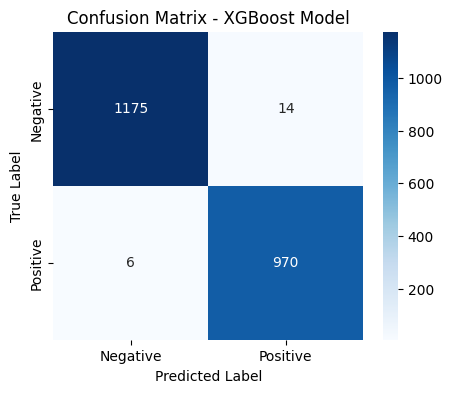

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost Model")
plt.show()

In [ ]:
print(X_test.columns)

Index(['id', 'age', 'juv_fel_count', 'decile_score', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'days_b_screening_arrest',
       'c_days_from_compas', 'is_recid', 'r_days_from_arrest', 'violent_recid',
       'is_violent_recid', 'decile_score.1', 'v_decile_score',
       'priors_count.1', 'start', 'end', 'event', 'sex_Female', 'sex_Male',
       'race_African-American', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Native American', 'race_Other',
       'age_cat_25 - 45', 'age_cat_Greater than 45', 'age_cat_Less than 25',
       'c_charge_degree_F', 'c_charge_degree_M', 'r_charge_degree_(CO3)',
       'r_charge_degree_(F1)', 'r_charge_degree_(F2)', 'r_charge_degree_(F3)',
       'r_charge_degree_(F5)', 'r_charge_degree_(F6)', 'r_charge_degree_(F7)',
       'r_charge_degree_(M1)', 'r_charge_degree_(M2)', 'r_charge_degree_(MO3)',
       'vr_charge_degree_(F1)', 'vr_charge_degree_(F2)',
       'vr_charge_degree_(F3)', 'vr_charge_degree_(F5)',
       'vr_c

In [ ]:
sensitive_feature = 'sex_Female'  # 假设'race'是敏感特征
for group in X_test[sensitive_feature].unique():
    group_indices = X_test[sensitive_feature] == group
    y_pred_group = xgb_cv.predict(X_test[group_indices])
    y_true_group = y_test[group_indices]
    print(f"Group {group}: Accuracy = {accuracy_score(y_true_group, y_pred_group)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true_group, y_pred_group)}")

Group False: Accuracy = 0.9902186421173763
Confusion Matrix:
[[901  12]
 [  5 820]]
Group True: Accuracy = 0.9929742388758782
Confusion Matrix:
[[274   2]
 [  1 150]]


In [ ]:
rf_model = RandomForestRegressor(random_state=42)  # 如果是回归任务，使用RandomForestRegressor
rf_model.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import cross_val_score
y_pred = rf_model.predict(X_test)
print("Random Forest MSE:", mean_squared_error(y_test, y_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred))
print("Random Forest R²:", r2_score(y_test, y_pred))

In [ ]:
# 随机森林训练时间
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time
print("Random Forest Training Time:", rf_train_time)

In [ ]:
rf_importance = rf_model.feature_importances_
feature_importance = list(zip(X.columns, rf_importance))

# 按特征重要性排序（从大到小）
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)

# 选择前10个最重要的特征
top_5_features = feature_importance_sorted[:5]

# 分离特征名称和重要性值
top_5_feature_names = [x[0] for x in top_5_features]
top_5_importance_values = [x[1] for x in top_5_features]

# 绘制水平条形图
plt.barh(top_5_feature_names, top_5_importance_values)
plt.title("Top 5 Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.show()

In [ ]:
def get_model_size(model, model_type):
    if model_type == 'xgb':
        num_trees = len(model.best_estimator_.get_booster().get_dump())
        max_depth = model.best_estimator_.get_booster().get_score(importance_type='weight').values()
        avg_depth = np.mean([int(d.split('=')[1].split(',')[0]) for d in model.best_estimator_.get_booster().get_dump()])
        return num_trees, avg_depth
    elif model_type == 'rf':

        num_trees = len(model.estimators_)
        avg_depth = np.mean([tree.tree_.max_depth for tree in model.estimators_])
        return num_trees, avg_depth

xgb_num_trees, xgb_avg_depth = get_model_size(xgb_cv, 'xgb')
rf_num_trees, rf_avg_depth = get_model_size(rf_model, 'rf')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(['XGBoost', 'Random Forest'], [xgb_num_trees, rf_num_trees], color=['blue', 'orange'])
ax[0].set_title('Number of Trees')
ax[0].set_ylabel('Count')

ax[1].bar(['XGBoost', 'Random Forest'], [xgb_avg_depth, rf_avg_depth], color=['blue', 'orange'])
ax[1].set_title('Average Tree Depth')
ax[1].set_ylabel('Depth')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training score')
    plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# 绘制XGBoost的学习曲线
plot_learning_curve(xgb_cv.best_estimator_, X_train, y_train, 'XGBoost Learning Curve')



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression


# 绘制学习曲线
def plot_learning_curve(model, X, y, title):
    # 使用回归任务的评分指标（如 neg_mean_squared_error 或 r2）
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
    )

    # 计算训练集和验证集的平均得分
    train_scores_mean = -np.mean(train_scores, axis=1)  # 取负值得到正MSE
    test_scores_mean = -np.mean(test_scores, axis=1)    # 取负值得到正MSE

    # 绘制学习曲线
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training score')
    plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Squared Error')  # Y轴表示均方误差
    plt.legend()
    plt.show()

# 调用函数绘制学习曲线
plot_learning_curve(rf_model, X_train, y_train, 'Random Forest Regression Learning Curve')